# BayesOpt-Human — Minimal Demo

This notebook walks through one full optimization step on a trivial 2D objective,
following the `get → report → choose` pattern at each phase:

1. **Data**: `get_data` → `report_data` → `choose_data`
2. **Model**: `get_models` → `report_models` → `choose_model`
3. **Candidate**: `get_candidates` → `report_candidates` → `choose_candidate`

The objective is evaluated inline to produce a warmstart CSV. In a real workflow,
you supply the CSV yourself and evaluate each recommended point externally.

## Setup: generate a warmstart CSV

Minimize a simple 2D quadratic bowl on `[-2, 2]^2` with a Sobol-sampled warmstart.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import qmc

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

BOUNDS = {"x1": (-2.0, 2.0), "x2": (-2.0, 2.0)}
N_WARMSTART = 8
HORIZON = 20

def objective(x1: np.ndarray, x2: np.ndarray) -> np.ndarray:
    return (x1 - 0.5) ** 2 + (x2 + 0.25) ** 2

sampler = qmc.Sobol(d=2, seed=0)
unit = sampler.random(N_WARMSTART)
lo = np.array([BOUNDS["x1"][0], BOUNDS["x2"][0]])
hi = np.array([BOUNDS["x1"][1], BOUNDS["x2"][1]])
xs = lo + unit * (hi - lo)
ys = objective(xs[:, 0], xs[:, 1])

df = pd.DataFrame({"x1": xs[:, 0], "x2": xs[:, 1], "y": ys})
csv_path = DATA_DIR / "demo.csv"
df.to_csv(csv_path, index=False)
df

,x1,x2,y
0,1.402342,1.725464,4.716679
1,-0.193740,-1.332252,1.652545
2,-1.005056,0.366581,2.645366
3,0.336614,-0.693088,0.223022
4,0.654753,0.845558,1.224195
5,-1.941327,-0.206056,5.962007
6,-0.750632,1.234714,3.768455
7,1.591041,-1.814946,3.639426


## Configure the optimization

In [2]:
from bayesopt_human import OptimizationConfig, OptimizationStep

config = OptimizationConfig(
    name="demo",
    warmstart=N_WARMSTART,
    horizon=HORIZON,
    bounds=BOUNDS,
    objective_column="y",
    direction="minimize",
    modality="unimodal",
)
step = OptimizationStep([config])

## 1. Data

In [3]:
data_result = step.get_data(str(DATA_DIR))

Found 1 data file:
  [0] demo.csv                       |   8 obs, 2 dims  | params: x1, x2


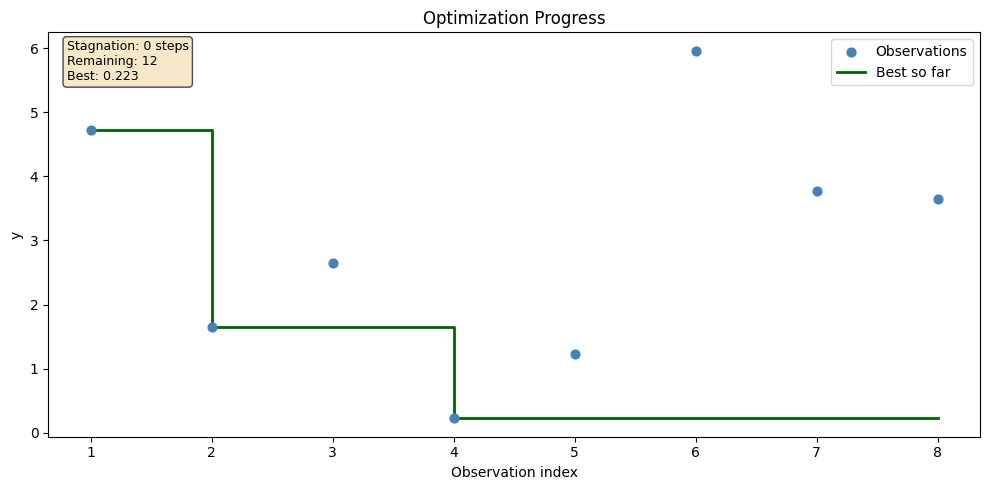

['progress']

In [4]:
step.report_data(data_result, report="progress", choice=0)

In [5]:
data = step.choose_data(data_result, choice=0)

Selected [0]: demo.csv (8 obs, 2 dims)


## 2. Model

In [6]:
model_result = step.get_models(data)

Evaluating output transforms (ARD + isotropic)...

Model Selection Results:


Idx,Transform,Kern,#Params,LOO-MAE,LPD,Var(r),Mean(r),FIT,LS,WRP,Notes
0,none,ISO,3,0.6305 ± 0.3276,-1.1207,0.7015,0.0458,●,●,—,[rec]
1,none,ARD,4,0.5554 ± 0.3210,-0.9966,0.6764,0.1268,●,●,—,
2,signed_log1p,ARD,4,0.5199 ± 0.3315,-1.0020,0.6920,0.0287,●,●,—,
3,signed_log1p,ISO,3,0.6075 ± 0.4113,-1.1506,0.7778,-0.0511,●,●,—,
4,log,ARD,4,0.6401 ± 0.6420,-1.3420,1.2657,-0.1075,●,●,—,
5,log,ISO,3,0.7022 ± 0.7362,-1.4633,1.3586,-0.2223,●,●,—,



Ranked by recommendation (LOO-LPD within sections). Models below the line are demoted.
RAG columns:
  FIT: calibration of LOO residuals (Var(r)).
       Red = Var(r) > 5.0 or < 0.1 (demoted). Amber = > 2.0 or < 0.5. Green = well-calibrated.
  LS:  length-scale diagnostics.
       Red = >= half at bounds (demoted). Amber = advisory. Green = no issues.
  WRP: warp parameter diagnostics (— = non-warp model).
       Red = >= half extreme (demoted). Amber = advisory. Green = no issues.

Recommendation (INITIAL): [0] none (ISO, LPD=-1.1207, LOO-MAE=0.6305 ± 0.3276, Var(r)=0.7015)
  First round. Picked the simplest model within 0.5 nats of the best LOO-LPD.


Diagnostics for [0]: none (ISO)

Observations in surrogate space (IQR)
  8 points, 2 dimensions, warmstart=8, direction=minimize

  #  Phase      obj (IQR)          x1          x2
-------------------------------------------------
  0  warm        0.639938     1.40234     1.72546
  1  warm       -0.605617    -0.19374    -1.33225
  2  warm        -0.20204    -1.00506    0.366581
  3  warm        -1.18671    0.336614   -0.693088  <-- best
  4  warm        -0.77974    0.654753    0.845558
  5  warm         1.14616    -1.94133   -0.206056
  6  warm         0.25449   -0.750632     1.23471
  7  warm         0.20204     1.59104    -1.81495
-------------------------------------------------
Best: observation #3 (-1.18671)


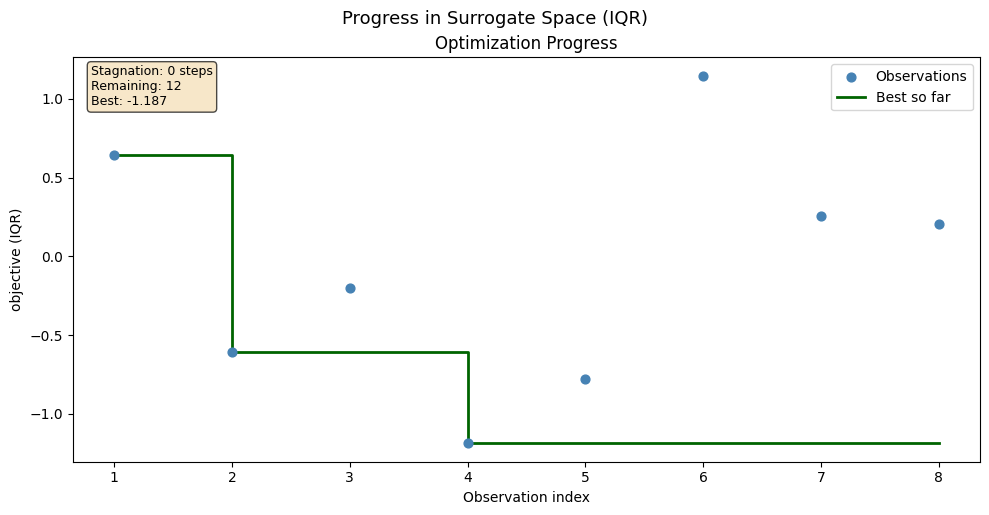

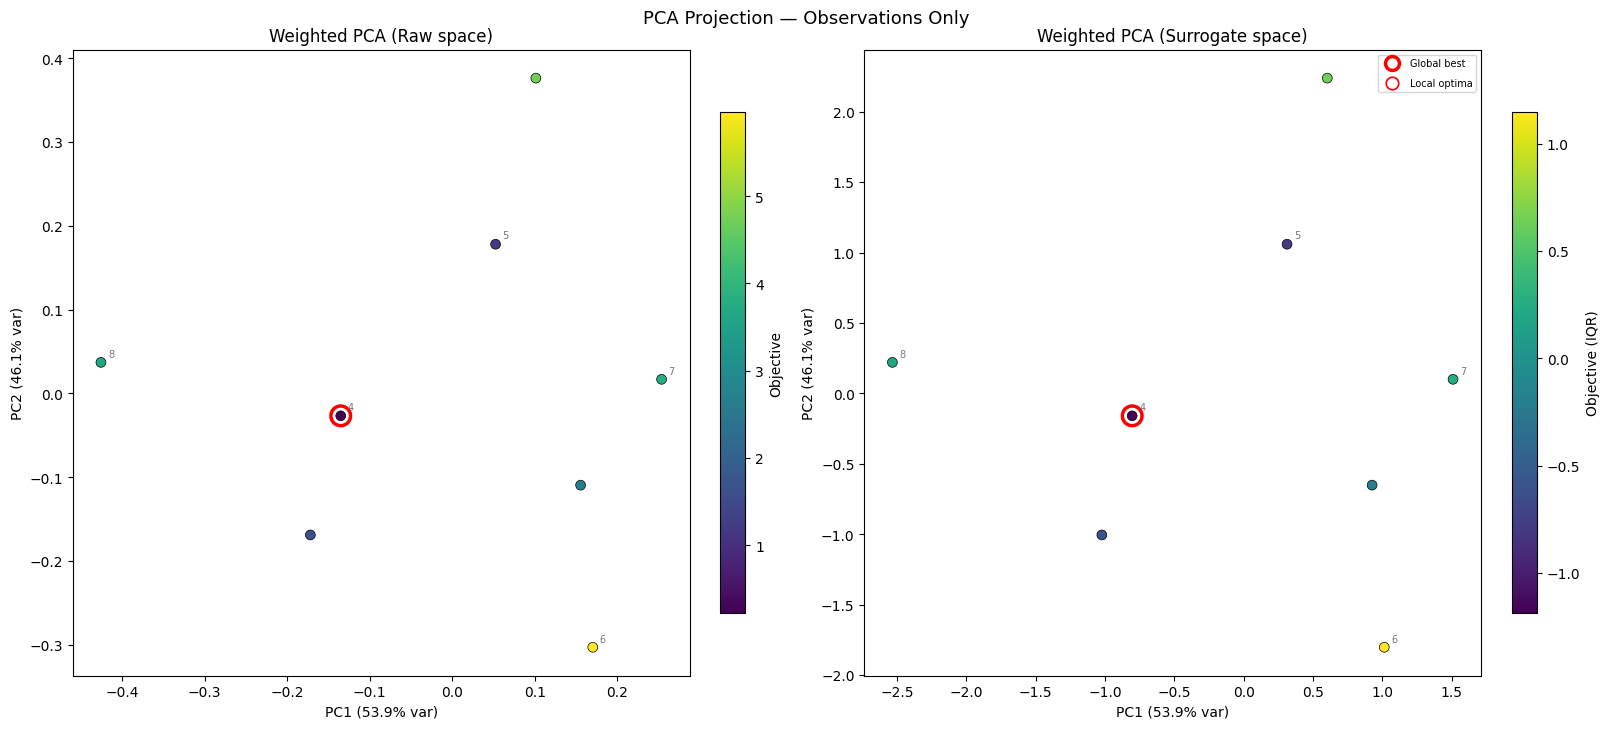

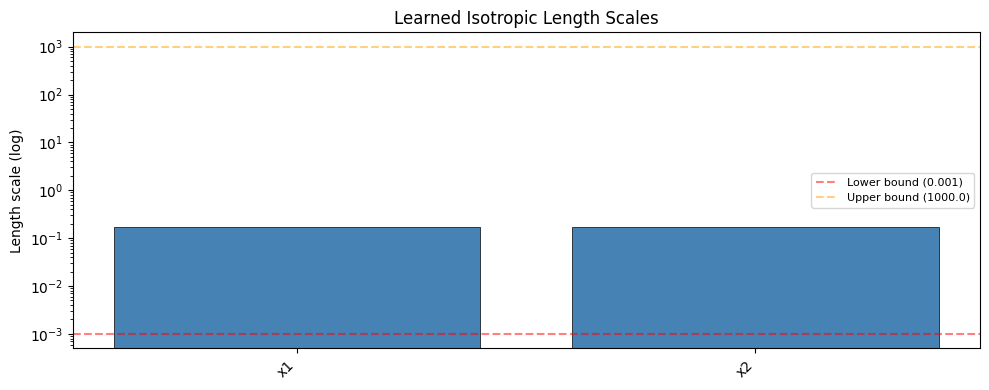

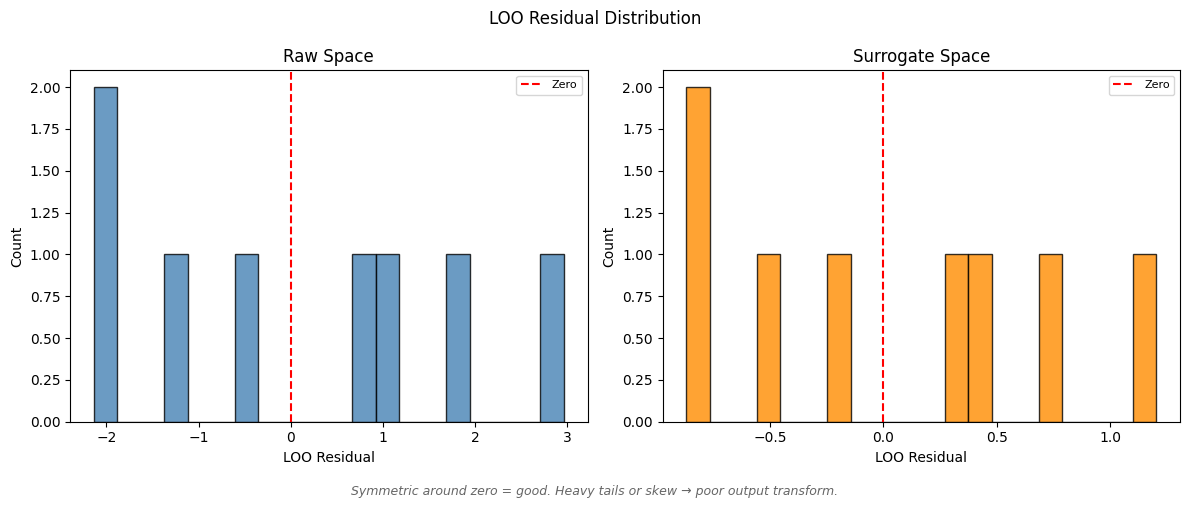

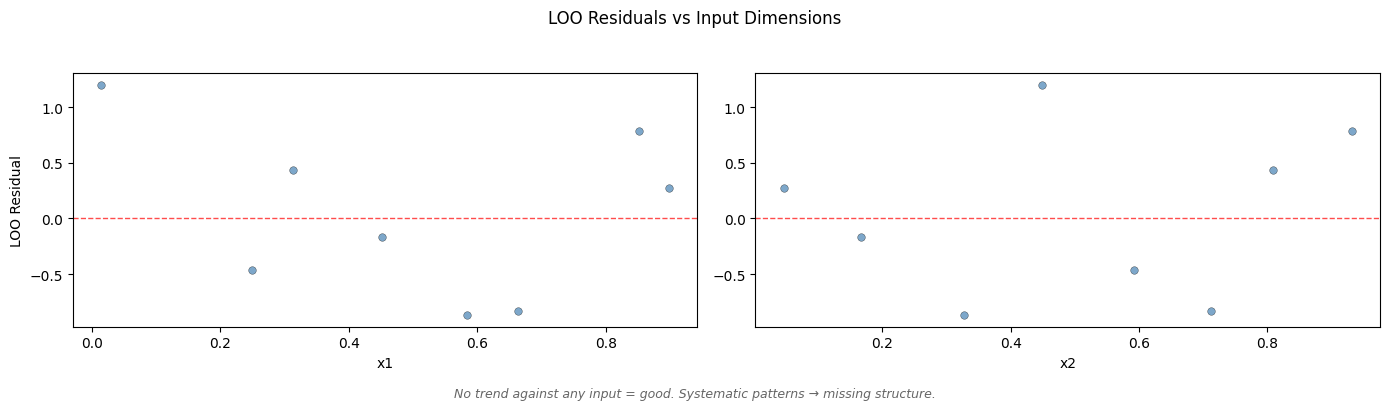

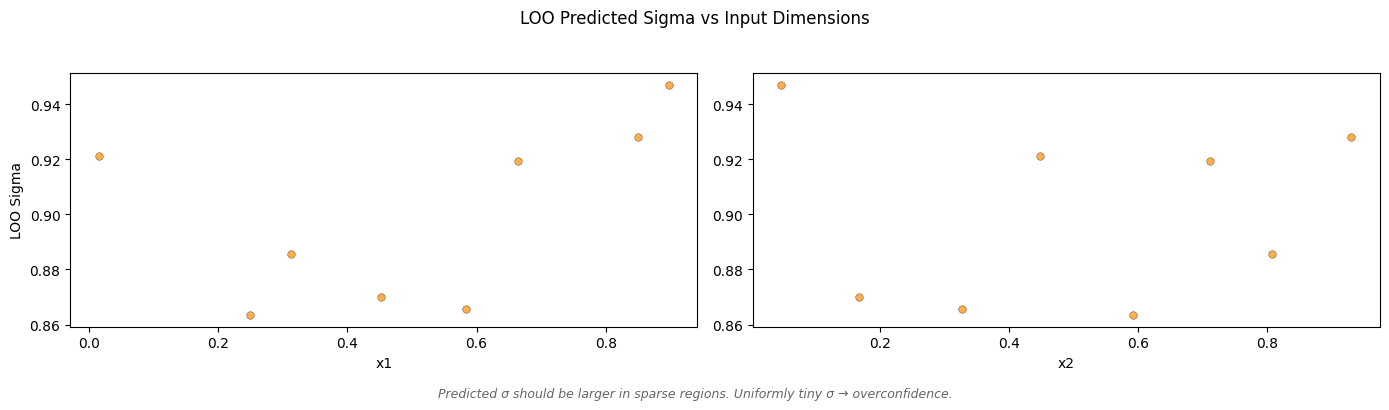

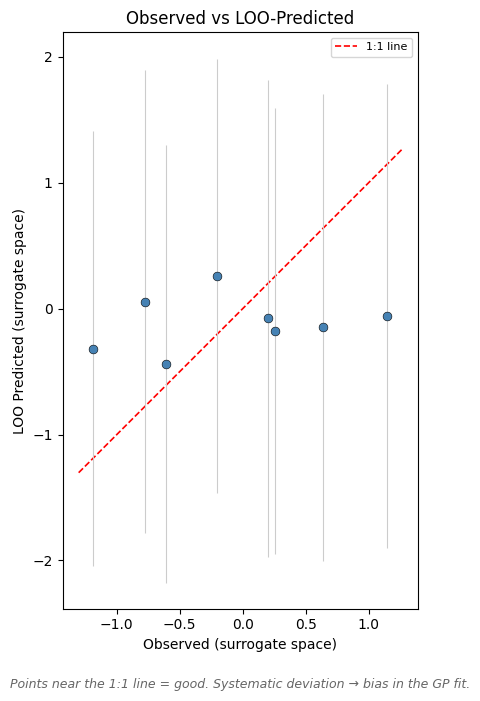

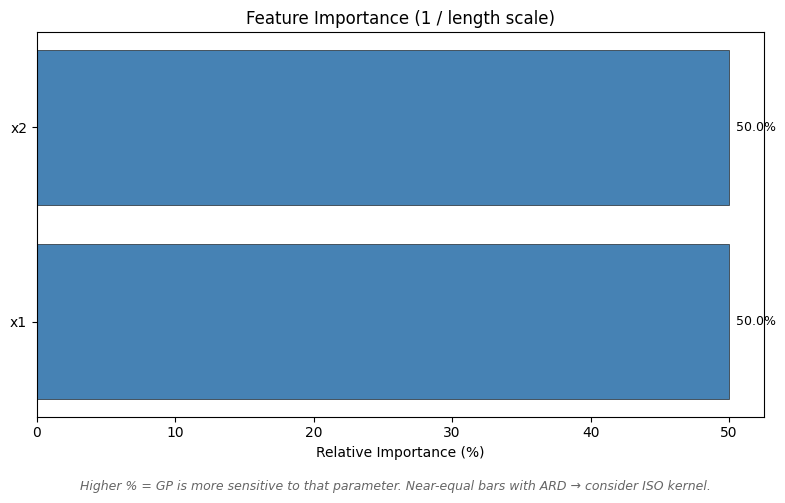

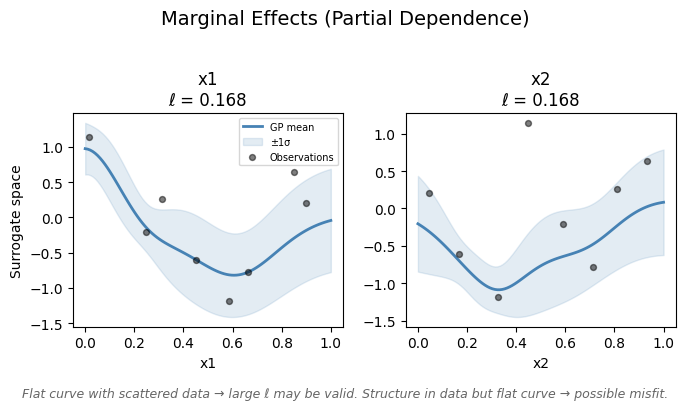

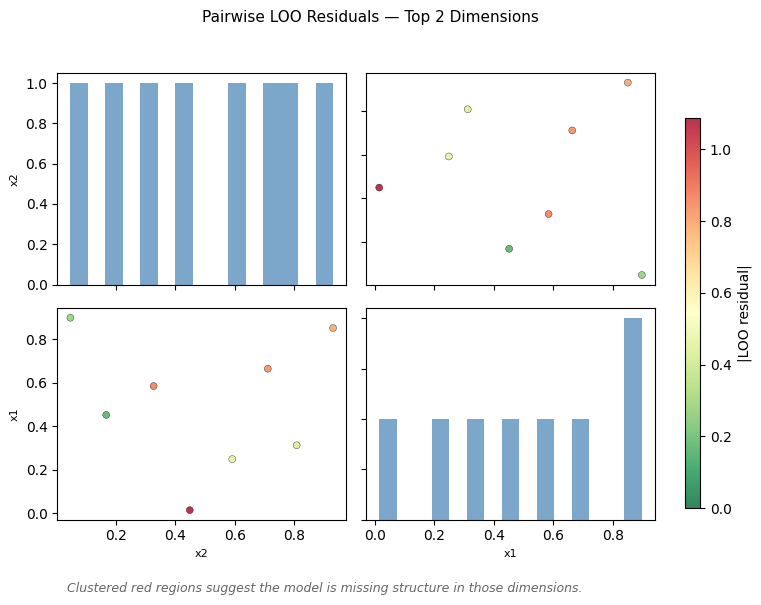


GP Fit Diagnostics: [0] none (ISO)
  LOO-MAE:          0.6305 ± 0.3276
  LOO-LPD:          -1.1207
  Conditioning:     -1.2658
  Jitter used:      5.27e-05
  Output transform: none
  Warping:          disabled

  Feature importances (1/length_scale):
    x1: ls=0.1681, importance=5.9496
    x2: ls=0.1681, importance=5.9496


['surrogate_observations',
 'surrogate_progress',
 'surrogate_pca',
 'hyperparameters',
 'residuals',
 'observed_vs_predicted',
 'feature_importance',
 'marginal_effects',
 'pairwise_projections',
 'gp_fit']

In [7]:
step.report_models(model_result, report="all", choice=0)

In [8]:
fitted_gp = step.choose_model(model_result, choice=0)

Selected model [0]: none (ISO, LPD=-1.1207, LOO-MAE=0.6305 ± 0.3276, Var(r)=0.7015)
  (Following INITIAL recommendation)


## 3. Candidate

In [9]:
cand_result = step.get_candidates(data, fitted_gp)

Generating candidates...
  Generated 8 candidates
Computing diagnostics...
Generating recommendations...

Candidate Comparison:
Rank                       Source        Category Sur. Mean Sur. Std      EI Cov. Gain (flat) Cov. Gain (surr.) SVM Pred.
  #1 Max-min distance (surrogate)   exploration ★   +0.0702  +0.7351 +0.0131        -0.004652          -0.02768        No
  #2         Expected Improvement      balanced ★   -0.9654  +0.5012 +0.1085          0.06538             0.389     Top Q
  #3       Max Posterior Variance     exploration   +0.0901  +0.7344 +0.0122        -0.002579          -0.01534        No
  #4      Max-min distance (flat) space-filling ★   +0.0702  +0.7351 +0.0131        -0.004652          -0.02768        No
  #5              LCB (kappa=low)    exploitation   -1.1307  +0.2859 +0.0882           0.0653            0.3885     Top Q
  #6           LCB (kappa=medium)        balanced   -0.8916  +0.5596 +0.1060          0.06521             0.388     Top Q
  #7             L


Observations and proposed candidate [Max-min distance (surrogate)]
  8 observations, 2 dimensions, warmstart=8, direction=minimize
  Distances computed in raw space. 5 closest highlighted.

  #  Phase       Distance     objective          x1          x2
-------------------------------------------------------------------------------
  5  warm         1.79575       5.96201    -1.94133   -0.206056  <-- closest #1
  1  warm         1.79575       1.65255    -0.19374    -1.33225  <-- closest #2
  2  warm         2.51652       2.64537    -1.00506    0.366581  <-- closest #3
  3  warm         2.55662      0.223022    0.336614   -0.693088  <-- closest #4, best
  6  warm          3.4199       3.76846   -0.750632     1.23471  <-- closest #5
  7  warm         3.45672       3.63943     1.59104    -1.81495
  4  warm           3.798       1.22419    0.654753    0.845558
  0  warm         4.95244       4.71668     1.40234     1.72546
-------------------------------------------------------------------

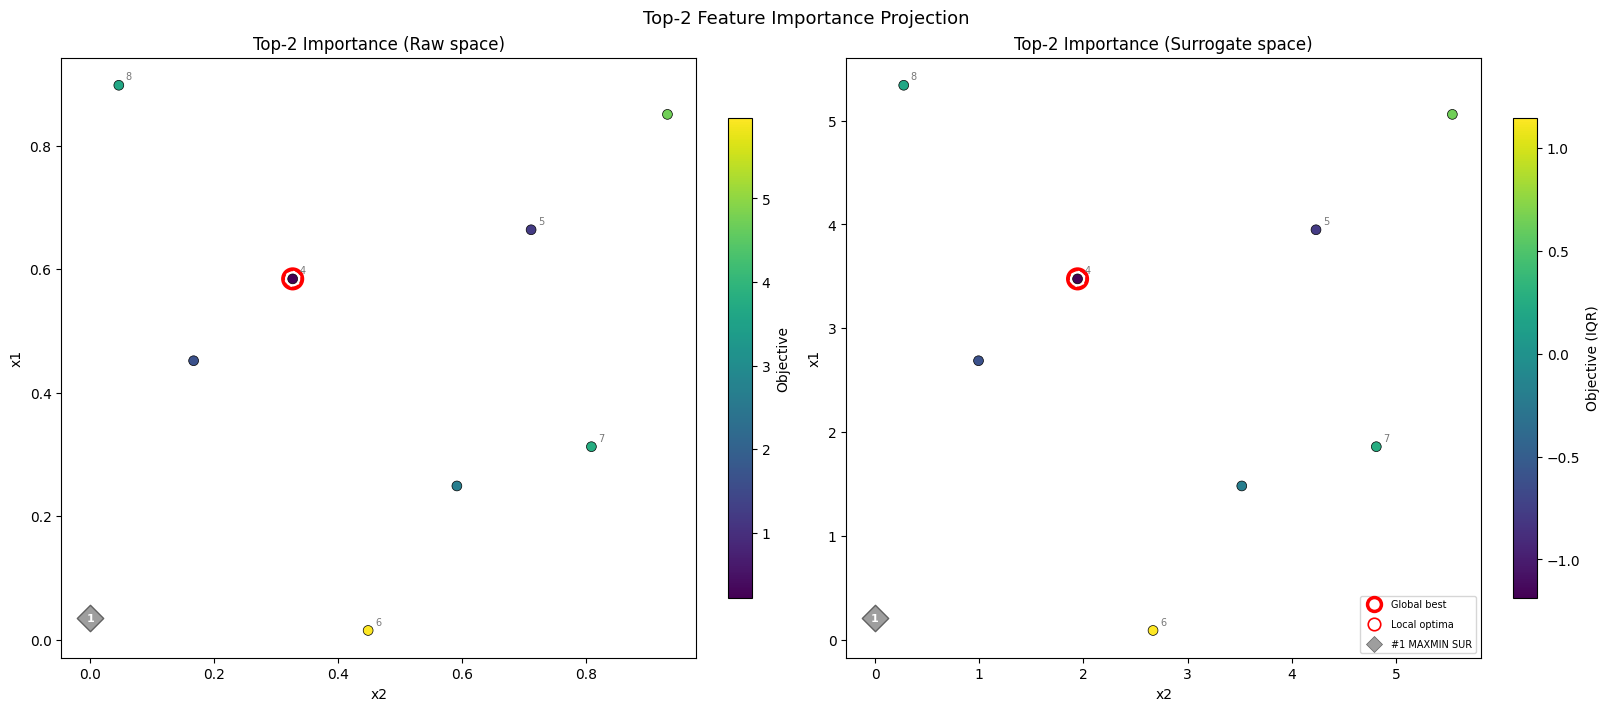

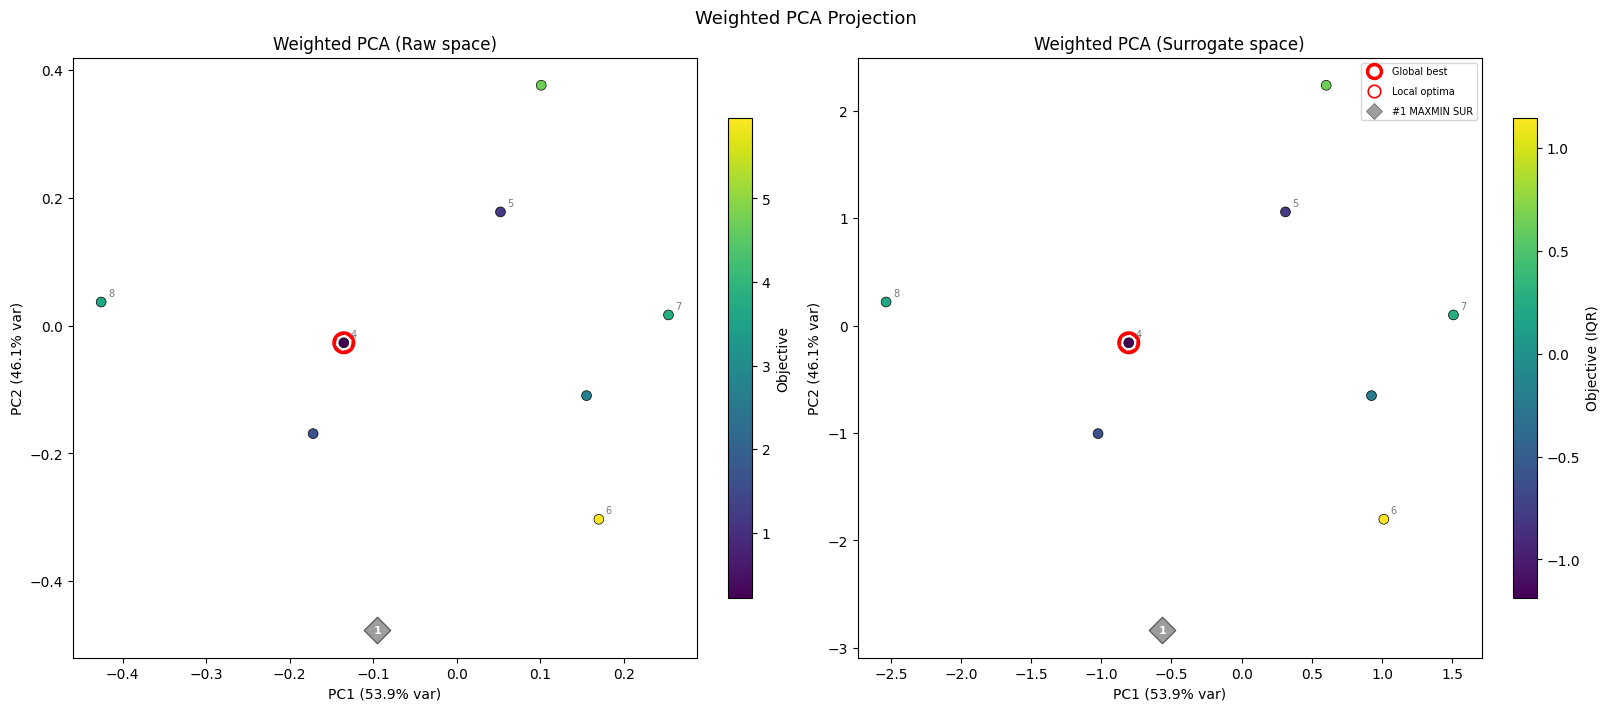

['observations_raw', 'observations_sur', 'importance_2d', 'pca_2d']

In [10]:
step.report_candidates(cand_result, report="all", choice=1)

In [11]:
next_point = step.choose_candidate(cand_result, choice=1)
print(f"\nNext evaluation point: {next_point}")

Selected rank #1: Max-min distance (surrogate)
  Raw coordinates: [-1.86072717 -1.99999992]

Next evaluation point: [-1.86072717 -1.99999992]


## Close the loop

In a real workflow you would now evaluate `next_point` externally, append the
result as a new row in `data/demo.csv`, and re-run the cells above. Here we do
it inline to demonstrate the full round trip.

In [12]:
new_y = float(objective(next_point[0], next_point[1]))
new_row = pd.DataFrame([{"x1": next_point[0], "x2": next_point[1], "y": new_y}])
df = pd.concat([df, new_row], ignore_index=True)
df.to_csv(csv_path, index=False)
df.tail()

,x1,x2,y
4,0.654753,0.845558,1.224195
5,-1.941327,-0.206056,5.962007
6,-0.750632,1.234714,3.768455
7,1.591041,-1.814946,3.639426
8,-1.860727,-2.000000,8.635532
